In [1]:
import numpy as np
from scipy.integrate import quad, simpson
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import csv

plt.style.use('sty.mplstyle')

# Define 3-parameter Fermi Model [Altmannshofer]

In [2]:
c_3pF = 3.73/0.1973 # GeV^{-1}
z_3pF = 0.62/0.1973 # GeV^{-1}
w_3pF = -0.19  # dimensionless
R_cutoff = (3.48/0.1973)*5 # GeV^{-1}

# Defining the functions
def rho3pF(x):
    num = 1 + w_3pF * (x**2/c_3pF**2)
    denom = 1 + np.exp( (x - c_3pF)/z_3pF )
    return num/denom

# Defining an auxiliary function
def rho3pF_aux(x, Q2):
    Q = np.sqrt(Q2)
    if Q == 0:
        return x**2 * rho3pF(x)
    else:
        return x**2 * np.sin(Q*x)/(Q*x) * rho3pF(x)

# Compute the quantity to normalize the form factor
norm, _ = quad( rho3pF_aux, 0, R_cutoff, args=(0,), limit=1000 )
        
# Defining the Form Factor
def Alt_FF(Q2):
    main, _ = quad( rho3pF_aux, 0, R_cutoff, args=(Q2,), limit=1000 )
    return main/norm

# Compute $u_1$ values [Altmannshofer against Christian]

In [3]:
def Alt_FF_squared(Q2):
    return Alt_FF(Q2)**2

def u1(Q2min):
    main, _ = quad(Alt_FF_squared, Q2min, np.inf)
    return main
u1 = np.vectorize(u1)

q2_Alt = np.loadtxt('../csv/InterpolationList/Argon/40Ar_InterpolationList3pF_Altmannshofer.txt', delimiter=',', usecols=0)
u1_Alt = np.loadtxt('../csv/InterpolationList/Argon/40Ar_InterpolationList3pF_Altmannshofer.txt', delimiter=',', usecols=1)
u1_Christian = u1(q2_Alt)

In [4]:
# Writing to CSV
with open("../csv/InterpolationList/Argon/40Ar_InterpolationList_3pF_Christian.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1_Christian):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

# Define the Helm Form Factor

In [5]:
# Argon Form Factor using the Helm Form Factor
def j1_aux(x):
    main = 1/3*np.ones_like(x)
    cond = x!=0
    num = np.sin(x[cond]) - x[cond]*np.cos(x[cond])
    denom = x[cond]**3
    main[cond] = num/denom
    return main
    
def Helm_FF(Q2, R0=1, s=1):
    Q2 = np.array([Q2])
    Q = np.sqrt(Q2)
    return 3*j1_aux(Q*R0)*np.exp( -Q2*s**2/2 )

# Define the parameters
A = 40
r0_Helm = 0.52 # fm
s_Helm = 0.9 # fm

R0_Helm = ( 1.23*A**(1/3) - 0.6 )**2 + 7*np.pi**2*r0_Helm**2/3 - 5*s_Helm**2 #fm^2
R0_Helm = np.sqrt(R0_Helm) # fm
R0_Helm = R0_Helm/0.1973 # GeV^{-1}
s_Helm = s_Helm/0.1973 # GeV^{-1}

def Helm_FF_squared(Q2):
    return Helm_FF(Q2, R0=R0_Helm, s=s_Helm)**2

def u1_Helm(Q2min):
    main, _ = quad(Helm_FF_squared, Q2min, np.inf)
    return main

u1_Helm = np.vectorize(u1_Helm)
u1_Helm_values = u1_Helm(q2_Alt)

In [6]:
# Writing to CSV
with open("../csv/InterpolationList/Argon/40Ar_InterpolationList_Helm_Christian.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1_Helm_values):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

# Define the Klein-Nystrand Form Factor

In [7]:
# Argon Form Factor using the Klein-Nystrand Form Factor
RA_KN = 1.23*A**(1/3) #fm
RA_KN = RA_KN/0.1973 # GeV^{-1}

def KN_FF(Q2, RA=1):
    Q2 = np.array([Q2])
    ak_aux = 0.7/0.1973 # GeV^{-1}
    Q = np.sqrt(Q2)
    return 3*j1_aux(Q*RA)/( 1 + Q2*ak_aux**2 )

def KN_FF_squared(Q2):
    return KN_FF(Q2, RA=RA_KN)**2

def u1_KN(Q2min):
    main, _ = quad(KN_FF_squared, Q2min, np.inf)
    return main

u1_KN = np.vectorize(u1_KN)
u1_KN_values = u1_KN(q2_Alt)

# Argon Form Factor using the Klein-Nystrand Form Factor (ad.)
r0_ad_KN = 3.427 # fm
ak_ad_KN = 0.7 # fm
RA_ad_KN = 5*r0_ad_KN**2/3 - 10*ak_ad_KN**2 #fm^2
RA_ad_KN = np.sqrt(RA_ad_KN) #fm
RA_ad_KN = RA_ad_KN/0.1973 # GeV^{-1}

def ad_KN_FF_squared(Q2):
    return KN_FF(Q2, RA=RA_ad_KN)**2

def u1_ad_KN(Q2min):
    main, _ = quad(ad_KN_FF_squared, Q2min, np.inf)
    return main

u1_ad_KN = np.vectorize(u1_ad_KN)
u1_ad_KN_values = u1_ad_KN(q2_Alt)

In [8]:
# Writing to CSV
with open("../csv/InterpolationList/Argon/40Ar_InterpolationList_KN_Christian.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1_KN_values):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

# Writing to CSV
with open("../csv/InterpolationList/Argon/40Ar_InterpolationList_adKN_Christian.txt", mode='w', newline="") as file:
    for q2val, u1val in zip(q2_Alt, u1_ad_KN_values):
        file.write(f"\t {q2val:.17f}, \t {u1val:.30f}, \n")

# Additional Nuclear Form Factors

In [9]:
HF_SKE2_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_HF-SKE2.dat', usecols=1) # fm^{-1}
HF_SKE2_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_HF-SKE2.dat', usecols=14)
q_HFSKE2 = HF_SKE2_xaxis*0.1973 # GeV
abs_HFSKE2 = np.abs( HF_SKE2_yaxis )

In [10]:
N2LO_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_N2LO.dat', usecols=0) # fm^{-1}
N2LO_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_N2LO.dat', usecols=1)
q_N2LO = N2LO_xaxis*0.1973 # GeV
abs_N2LO = np.abs( N2LO_yaxis )

In [11]:
RMF_xaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_RMF.dat.txt', usecols=0) # fm^{-1}
RMF_yaxis = np.loadtxt('../csv/FormFactors/Fw_40Ar_RMF.dat.txt', usecols=1)
q_RMF = RMF_xaxis*0.1973
abs_RMF = np.abs( RMF_yaxis )

In [12]:
q_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=0) # fm^{-1}
q_ShellModel = q_ShellModel*0.1973 # GeV
Fp_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=1)
Fn_ShellModel = np.loadtxt('../csv/FormFactors/Fp_Fn_40Ar_EFT_ShellModel.dat', usecols=2)
Z_aux = 18
A_aux = 40
N_aux = A_aux - Z_aux
sin2Thetaw = 0.23119
QW = (1 - 4*sin2Thetaw)*Z_aux - N_aux
Fw_ShellModel = ( (1-4*sin2Thetaw)*Z_aux*Fp_ShellModel**2 - N_aux*Fn_ShellModel**2 )/QW
abs_Fw_ShellModel = np.abs( Fw_ShellModel )

In [13]:
def Compute_u1(Q, FF):
    u1 = np.zeros_like(Q)
    for i in range(len(Q)):
        x = Q[i:]**2
        y = FF[i:]**2
        u1[i] = simpson(y,x)
    return u1

In [14]:
u1_HFSKE2_values = Compute_u1(q_HFSKE2, abs_HFSKE2)
u1_N2LO_values = Compute_u1(q_N2LO, abs_N2LO)
u1_RMF_values = Compute_u1(q_RMF, abs_RMF)
u1_ShellModel_values = Compute_u1(q_ShellModel, abs_Fw_ShellModel)

# Plotting the $u_1$ values

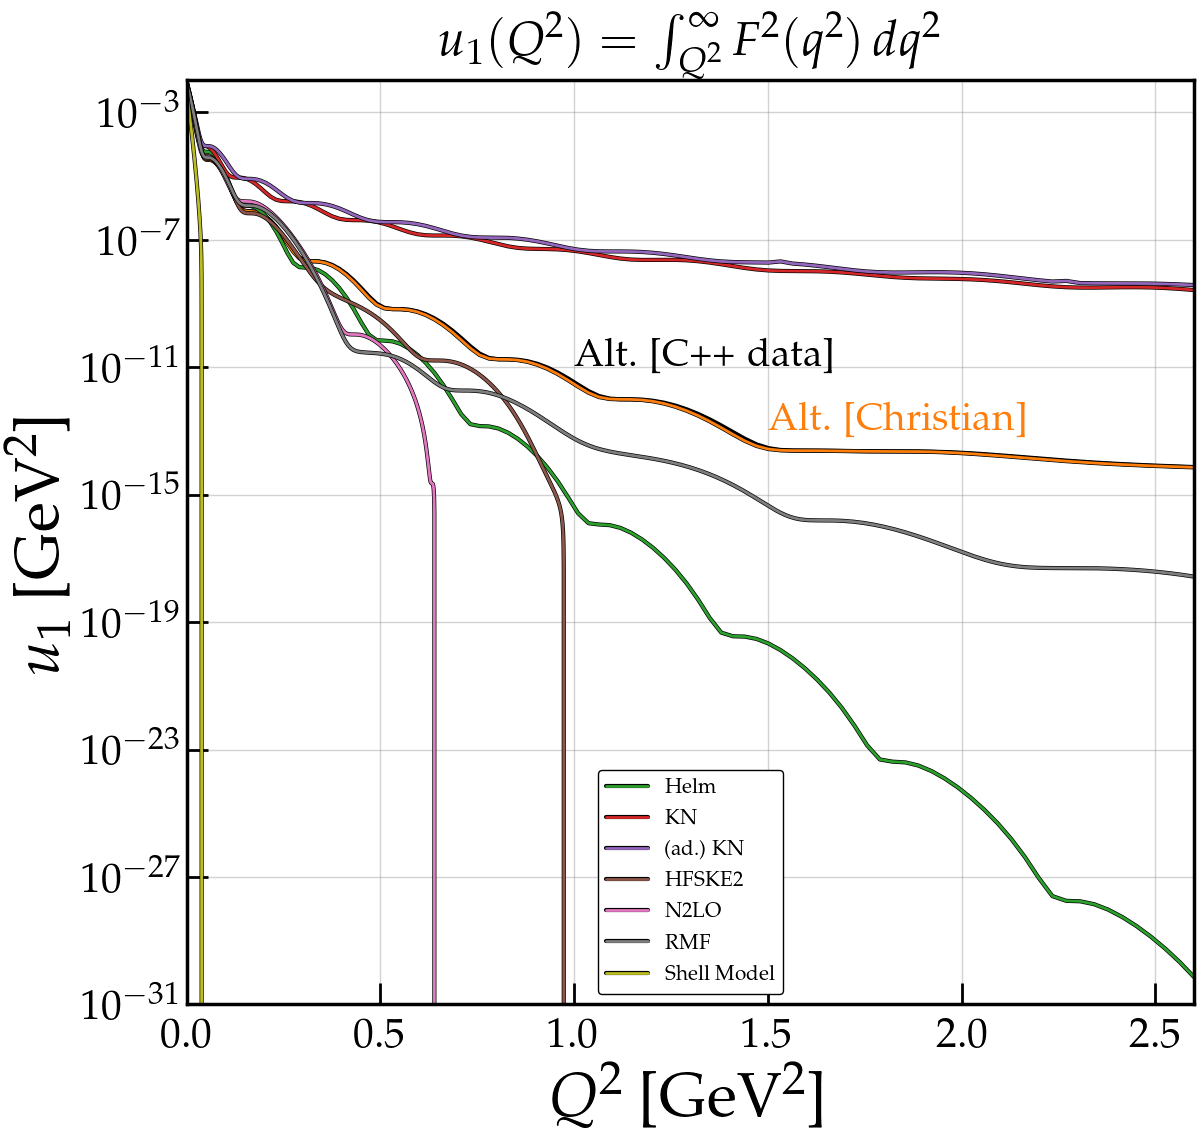

In [15]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(q2_Alt, u1_Alt, lw=2, color='black', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q2_Alt, u1_Christian, lw=2, color='#ff7f0e', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q2_Alt, u1_Helm_values, lw=2, color='#2ca02c', label='Helm', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q2_Alt, u1_KN_values, lw=2, color='#d62728', label='KN', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q2_Alt, u1_ad_KN_values, lw=2, color='#9467bd', label='(ad.) KN', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q_HFSKE2**2, u1_HFSKE2_values, lw=2, color='#8c564b', label='HFSKE2', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q_N2LO**2, u1_N2LO_values, lw=2, color='#e377c2', label='N2LO', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q_RMF**2, u1_RMF_values, lw=2, color='#7f7f7f', label='RMF', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
ax.plot(q_ShellModel**2, u1_ShellModel_values, lw=2, color='#bcbd22', label='Shell Model', path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])

ax.set_ylim([1e-31,1e-2])
ax.set_xlim( [0, q2_Alt.max()] )
ax.set_yscale('log')
ax.set_xlabel(r'$Q^2$ [GeV$^2$]')
ax.set_ylabel(r'$u_1$ [GeV$^2$]')
ax.xaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.yaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.legend(fontsize=15, frameon=True, framealpha=1, edgecolor='k', fancybox=True)
ax.tick_params(which='both', right=False, top=False, tickdir='in')
ax.set_title(r'$u_1(Q^2) = \int_{Q^2}^{\infty} F^2(q^2) \, dq^2$', pad = 20)

ax.text(1,1e-11,r'Alt. [C++ data]', color='black')
ax.text(1.5,1e-13,r'Alt. [Christian]', color='#ff7f0e')

plt.savefig('../Plots/Figures_PDF/40Argon_u1values.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/40Argon_u1values.png', transparent=False, bbox_inches='tight')

# Plotting the Form Factors

In [16]:
Alt_FF = np.vectorize(Alt_FF)
Q_max = np.sqrt(2.6) #GeV
Qval = np.linspace(0, Q_max, 500) #GeV
Alt_FF_abs = np.abs( Alt_FF(Qval**2) )

In [17]:
Helm_FF_abs = np.abs( Helm_FF(Qval**2, R0=R0_Helm, s=s_Helm) )[0]

In [18]:
KN_FF_abs = np.abs( KN_FF(Qval**2, RA=RA_KN) )[0]

In [19]:
ad_KN_FF_abs = np.abs( KN_FF(Qval**2, RA=RA_ad_KN) )[0]

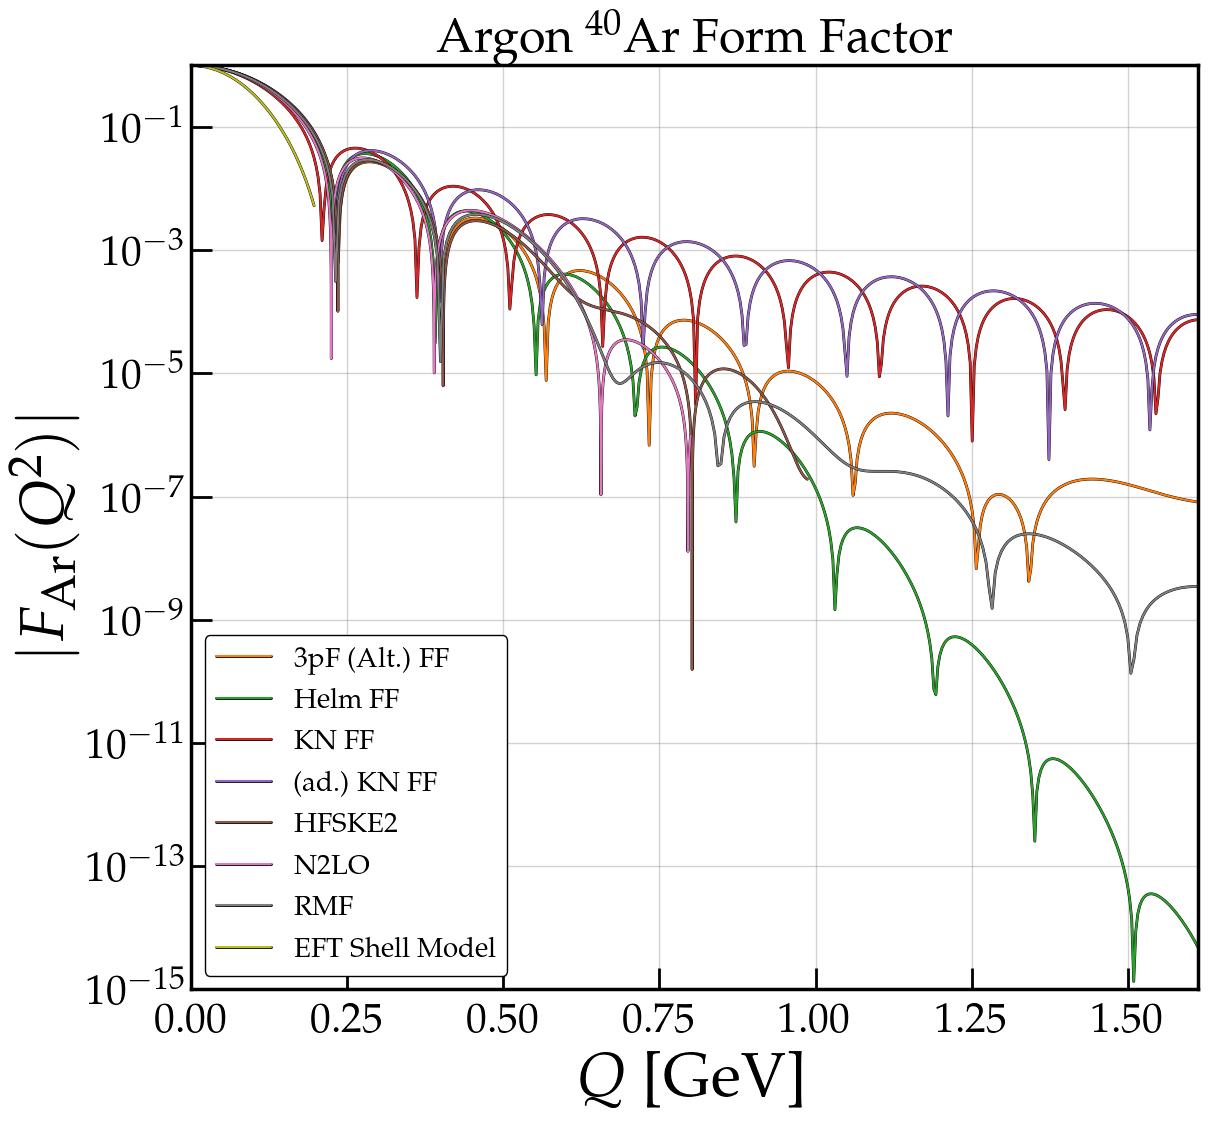

In [20]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Qval, Alt_FF_abs, lw=1.5, color='#ff7f0e', label='3pF (Alt.) FF', path_effects=[pe.Stroke(linewidth=2, foreground='k'), pe.Normal()])
ax.plot(Qval, Helm_FF_abs, lw=1.5, color='#2ca02c', label='Helm FF', path_effects=[pe.Stroke(linewidth=2, foreground='k'), pe.Normal()])
ax.plot(Qval, KN_FF_abs, lw=1.5, color='#d62728', label='KN FF', path_effects=[pe.Stroke(linewidth=2, foreground='k'), pe.Normal()])
ax.plot(Qval, ad_KN_FF_abs, lw=1.5, color='#9467bd', label='(ad.) KN FF', path_effects=[pe.Stroke(linewidth=2, foreground='k'), pe.Normal()])
ax.plot(q_HFSKE2, abs_HFSKE2, lw=1.5, color='#8c564b', label='HFSKE2', path_effects=[pe.Stroke(linewidth=2, foreground='k'), pe.Normal()])
ax.plot(q_N2LO, abs_N2LO, lw=1.5, color='#e377c2', label='N2LO', path_effects=[pe.Stroke(linewidth=2, foreground='k'), pe.Normal()])
ax.plot(q_RMF, abs_RMF, lw=1.5, color='#7f7f7f', label='RMF', path_effects=[pe.Stroke(linewidth=2, foreground='k'), pe.Normal()])
ax.plot(q_ShellModel, abs_Fw_ShellModel, lw=1.5, color='#bcbd22', label='EFT Shell Model', path_effects=[pe.Stroke(linewidth=2, foreground='k'), pe.Normal()])

ax.set_yscale('log')
ax.set_ylim([1e-15, 1])
ax.set_xlim([0, Qval.max()])

ax.legend(fontsize=20, frameon=True, framealpha=1, edgecolor='k', fancybox=True)
ax.xaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.yaxis.grid(True, ls='-', which='both', color='gray', alpha=0.35)
ax.tick_params(which='both', right=False, top=False, tickdir='in')
ax.set_xlabel(r'$Q$ [GeV]')
ax.set_ylabel(r'$ |F_{\mathrm{Ar}}(Q^2)| $')
ax.set_title(r'Argon $^{40}$Ar Form Factor')

plt.savefig('../Plots/Figures_PDF/40ArgonFF_wholerange.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/40ArgonFF_wholerange.png', transparent=False, bbox_inches='tight')